# PIE Replication Results Dashboard
**LLM-Based Personal Information Extraction — Liu et al. USENIX Security 2025**

Run this notebook from inside your `LLM-Based-Personal-Profile-Extraction/` directory with `pie_env` active.

In [1]:
# Install dependencies if needed
import subprocess
for pkg in ['matplotlib', 'numpy', 'rouge']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run(['pip', 'install', pkg], check=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from rouge import Rouge
import os

rouge = Rouge()

# ── Config ────────────────────────────────────────────────
BASE       = './result/groq_llama-3.1-8b-instant'
PROVIDER   = 'groq'
MODEL      = 'llama-3.1-8b-instant'
DATASET    = 'synthetic'
CATEGORIES = ['name', 'email', 'mail', 'phone', 'work', 'education', 'affiliation', 'occupation']
CAT_LABELS = ['Name', 'Email', 'Mail Addr.', 'Phone', 'Work Exp.', 'Education', 'Affiliation', 'Occupation']
DEFENSES   = ['no', 'replace_at', 'replace_dot', 'replace_at_dot', 'hyperlink', 'mask']
DEF_LABELS = ['No defense\n(baseline)', 'Replace @', 'Replace .', 'Replace @+.', 'Hyperlink', 'Name mask']

# Paper benchmarks (BERT scores from Table 3, Synthetic dataset)
PAPER = {
    'GPT-4':      [1.00, 1.00, 0.85, 0.98, 0.57, 0.63, 0.85, 0.70],
    'GPT-3.5':    [0.89, 0.96, 0.81, 0.85, 0.56, 0.58, 0.86, 0.67],
    'Vicuna-13B': [1.00, 0.59, 0.61, 0.57, 0.46, 0.59, 0.65, 0.65],
}

print('Config loaded.')

Config loaded.


In [3]:
# ── Helper: load and score a result file ──────────────────
def load_scores(defense):
    path = f'{BASE}/{DATASET}_{defense}_direct_0_adaptive_attack_no/all_raw_responses.npz'
    if not os.path.exists(path):
        print(f'  [missing] {path}')
        return None, None
    data = np.load(path, allow_pickle=True)
    res   = data['res'].item()
    label = data['label'].item()
    scores = {}
    for cat in CATEGORIES:
        preds  = res.get(cat, [])
        labels = label.get(cat, [])
        if cat in ['email', 'phone']:
            correct = sum(1 for p, l in zip(preds, labels)
                          if p.strip().lower() == l.strip().lower())
            scores[cat] = correct / len(preds) if preds else 0
        else:
            vals = []
            for p, l in zip(preds, labels):
                if p.strip() and l.strip():
                    try:
                        s = rouge.get_scores(p, l)[0]['rouge-1']['f']
                    except:
                        s = 0
                else:
                    s = 0
                vals.append(s)
            scores[cat] = sum(vals) / len(vals) if vals else 0
    return scores, res

# Load baseline
baseline_scores, _ = load_scores('no')
if baseline_scores:
    print('Baseline scores loaded:')
    for cat, label in zip(CATEGORIES, CAT_LABELS):
        print(f'  {label:<14}: {baseline_scores[cat]:.4f}')
else:
    print('ERROR: baseline result not found. Make sure run.py completed successfully.')

Baseline scores loaded:
  Name          : 0.9786
  Email         : 0.9400
  Mail Addr.    : 0.7571
  Phone         : 0.9700
  Work Exp.     : 0.4929
  Education     : 0.7449
  Affiliation   : 0.6586
  Occupation    : 0.6821


In [4]:
# ── Load defense scores ───────────────────────────────────
defense_email_scores = []
for defense in DEFENSES:
    scores, _ = load_scores(defense)
    if scores:
        defense_email_scores.append(scores.get('email', 0))
    else:
        defense_email_scores.append(None)

print('Defense email scores:')
for d, s in zip(DEF_LABELS, defense_email_scores):
    label = f'{s:.4f}' if s is not None else 'MISSING'
    print(f'  {d.replace(chr(10), " "):<22}: {label}')

Defense email scores:
  No defense (baseline) : 0.9400
  Replace @             : 0.1212
  Replace .             : 0.0707
  Replace @+.           : 0.0202
  Hyperlink             : 0.6364
  Name mask             : 0.1053


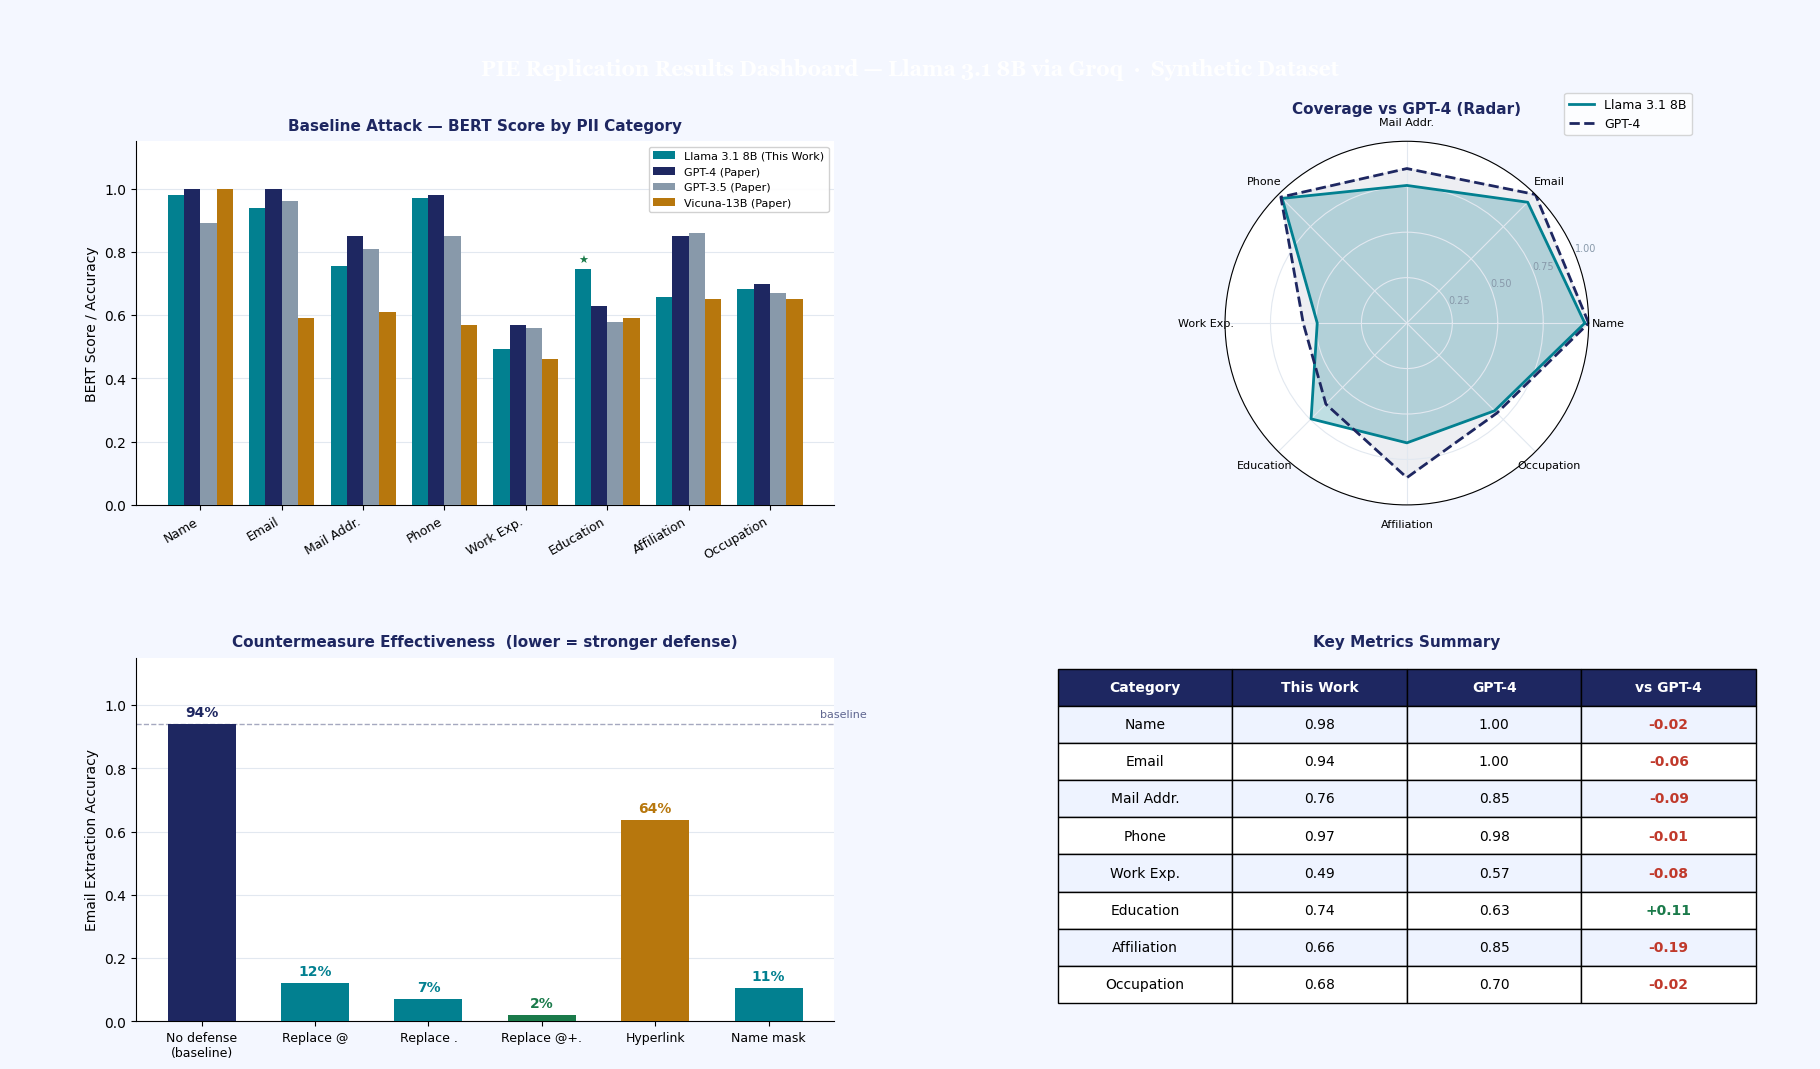


Dashboard saved to: pie_results_dashboard.png


In [5]:
# ── Dashboard ─────────────────────────────────────────────
NAVY   = '#1E2761'
TEAL   = '#028090'
TEAL_L = '#B2E4EC'
AMBER  = '#B7770D'
GREEN  = '#1A7A4A'
GRAY   = '#8899AA'
RED    = '#C0392B'
WHITE  = '#FFFFFF'
LIGHT  = '#F4F7FF'

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(LIGHT)
gs = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32,
              left=0.07, right=0.97, top=0.88, bottom=0.08)

# ── Title banner ──────────────────────────────────────────
fig.add_axes([0, 0.91, 1, 0.09]).set_axis_off()
fig.axes[-1].set_facecolor(NAVY)
fig.text(0.5, 0.945, 'PIE Replication Results Dashboard — Llama 3.1 8B via Groq  ·  Synthetic Dataset',
         ha='center', va='center', fontsize=15, fontweight='bold',
         color=WHITE, fontfamily='Georgia')

# ─────────────────────────────────────────────────────────
# PANEL 1: Baseline BERT scores vs paper models
# ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(WHITE)

x = np.arange(len(CATEGORIES))
w = 0.2
our_vals = [baseline_scores[c] for c in CATEGORIES] if baseline_scores else [0]*8

bars0 = ax1.bar(x - 1.5*w, our_vals,            w, label='Llama 3.1 8B (This Work)', color=TEAL,   zorder=3)
bars1 = ax1.bar(x - 0.5*w, PAPER['GPT-4'],      w, label='GPT-4 (Paper)',             color=NAVY,   zorder=3)
bars2 = ax1.bar(x + 0.5*w, PAPER['GPT-3.5'],    w, label='GPT-3.5 (Paper)',           color=GRAY,   zorder=3)
bars3 = ax1.bar(x + 1.5*w, PAPER['Vicuna-13B'], w, label='Vicuna-13B (Paper)',        color=AMBER,  zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(CAT_LABELS, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('BERT Score / Accuracy', fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title('Baseline Attack — BERT Score by PII Category', fontsize=11, fontweight='bold', color=NAVY, pad=8)
ax1.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8, loc='upper right', framealpha=0.9)

# Annotate where we beat GPT-4
for i, (ours, gpt4) in enumerate(zip(our_vals, PAPER['GPT-4'])):
    if ours >= gpt4:
        ax1.text(x[i] - 1.5*w, ours + 0.02, '★', ha='center', fontsize=8, color=GREEN)

# ─────────────────────────────────────────────────────────
# PANEL 2: Radar chart of our results vs GPT-4
# ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], polar=True)
ax2.set_facecolor(WHITE)

angles = np.linspace(0, 2*np.pi, len(CATEGORIES), endpoint=False).tolist()
angles += angles[:1]

our_radar  = our_vals + our_vals[:1]
gpt4_radar = PAPER['GPT-4'] + PAPER['GPT-4'][:1]

ax2.plot(angles, our_radar,  color=TEAL, linewidth=2, label='Llama 3.1 8B')
ax2.fill(angles, our_radar,  color=TEAL, alpha=0.25)
ax2.plot(angles, gpt4_radar, color=NAVY, linewidth=2, linestyle='--', label='GPT-4')
ax2.fill(angles, gpt4_radar, color=NAVY, alpha=0.08)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(CAT_LABELS, fontsize=8)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color=GRAY)
ax2.yaxis.grid(True, color='#E2E8F0')
ax2.xaxis.grid(True, color='#E2E8F0')
ax2.set_title('Coverage vs GPT-4 (Radar)', fontsize=11, fontweight='bold', color=NAVY, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)

# ─────────────────────────────────────────────────────────
# PANEL 3: Defense bar chart
# ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(WHITE)

def_colors = [NAVY, TEAL, TEAL, GREEN, AMBER, TEAL]
valid_scores = [s if s is not None else 0 for s in defense_email_scores]

bars = ax3.bar(range(len(DEFENSES)), valid_scores, color=def_colors, zorder=3, width=0.6)

for bar, val in zip(bars, valid_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.0%}', ha='center', va='bottom', fontsize=10,
             fontweight='bold', color=bar.get_facecolor())

ax3.set_xticks(range(len(DEFENSES)))
ax3.set_xticklabels(DEF_LABELS, fontsize=9)
ax3.set_ylabel('Email Extraction Accuracy', fontsize=10)
ax3.set_ylim(0, 1.15)
ax3.set_title('Countermeasure Effectiveness  (lower = stronger defense)', fontsize=11, fontweight='bold', color=NAVY, pad=8)
ax3.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)
ax3.axhline(y=valid_scores[0], color=NAVY, linestyle='--', linewidth=1, alpha=0.4, zorder=2)
ax3.text(5.45, valid_scores[0] + 0.02, 'baseline', fontsize=8, color=NAVY, alpha=0.7)

# ─────────────────────────────────────────────────────────
# PANEL 4: Summary stats table
# ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(WHITE)
ax4.axis('off')
ax4.set_title('Key Metrics Summary', fontsize=11, fontweight='bold', color=NAVY, pad=8)

table_data = []
col_labels = ['Category', 'This Work', 'GPT-4', 'vs GPT-4']
for i, (cat, clabel) in enumerate(zip(CATEGORIES, CAT_LABELS)):
    ours = our_vals[i]
    gpt4 = PAPER['GPT-4'][i]
    diff = ours - gpt4
    diff_str = f'+{diff:.2f}' if diff >= 0 else f'{diff:.2f}'
    table_data.append([clabel, f'{ours:.2f}', f'{gpt4:.2f}', diff_str])

table = ax4.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0.05, 1, 0.92]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor(NAVY)
    table[0, j].set_text_props(color=WHITE, fontweight='bold')

# Style rows
for i, row in enumerate(table_data):
    bg = '#EEF3FF' if i % 2 == 0 else WHITE
    diff_val = float(row[3])
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(bg)
        if j == 3:
            color = GREEN if diff_val >= 0 else RED
            table[i+1, j].set_text_props(color=color, fontweight='bold')

plt.suptitle('', y=0)  # suppress default suptitle
plt.savefig('pie_results_dashboard.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()
print('\nDashboard saved to: pie_results_dashboard.png')

In [6]:
# ── Bonus: print full results table ───────────────────────
print('='*65)
print(f'{"Category":<16} {"This Work":>10} {"GPT-4":>10} {"GPT-3.5":>10} {"Vicuna-13B":>12}')
print('-'*65)
for i, (cat, clabel) in enumerate(zip(CATEGORIES, CAT_LABELS)):
    ours = our_vals[i]
    star = ' ★' if ours >= PAPER['GPT-4'][i] else '  '
    print(f'{clabel:<16} {ours:>9.2f}{star} {PAPER["GPT-4"][i]:>10.2f} {PAPER["GPT-3.5"][i]:>10.2f} {PAPER["Vicuna-13B"][i]:>12.2f}')
print('='*65)
print('★ = matches or beats GPT-4')

print()
print('Defense Results (email accuracy):')
print('-'*40)
for d, s in zip(DEF_LABELS, defense_email_scores):
    if s is not None:
        reduction = (1 - s/defense_email_scores[0]) * 100 if defense_email_scores[0] else 0
        print(f'{d.replace(chr(10), " "):<22}: {s:.2%}  (−{reduction:.0f}% vs baseline)')
    else:
        print(f'{d.replace(chr(10), " "):<22}: MISSING')

Category          This Work      GPT-4    GPT-3.5   Vicuna-13B
-----------------------------------------------------------------
Name                  0.98         1.00       0.89         1.00
Email                 0.94         1.00       0.96         0.59
Mail Addr.            0.76         0.85       0.81         0.61
Phone                 0.97         0.98       0.85         0.57
Work Exp.             0.49         0.57       0.56         0.46
Education             0.74 ★       0.63       0.58         0.59
Affiliation           0.66         0.85       0.86         0.65
Occupation            0.68         0.70       0.67         0.65
★ = matches or beats GPT-4

Defense Results (email accuracy):
----------------------------------------
No defense (baseline) : 94.00%  (−0% vs baseline)
Replace @             : 12.12%  (−87% vs baseline)
Replace .             : 7.07%  (−92% vs baseline)
Replace @+.           : 2.02%  (−98% vs baseline)
Hyperlink             : 63.64%  (−32% vs baseline)
Name